# Flipkart Water Purifiers Web Scraping and Data Analysis using Python

## Project Overview

This project extracts Flipkart water purifier product data using Python and BeautifulSoup. The collected data is cleaned, validated, and analyzed using Pandas and NumPy, followed by visualizations in Matplotlib to identify pricing trends, customer ratings, and product insights.

## Import Libraries
This project uses Python libraries for web scraping, data manipulation, and visualization.

**Libraries Used:**
- Requests
- BeautifulSoup
- Pandas
- NumPy
- Matplotlib

In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import re
import requests
from bs4 import BeautifulSoup
import warnings
warnings.filterwarnings("ignore")

## Web Scraping

The product information is extracted from Flipkart using the Requests library and BeautifulSoup. The scraped data includes product names, prices, ratings, and other details.

## Create Dataset

The extracted product information is organized into a structured dataset using Pandas for further analysis.

In [2]:
#Load Dataset into df
df = pd.read_csv('flipkart_purifiers.csv')
df

,product_name,price,Ratings,Features,pagenum,Originalprice,Discount,Review
0,NATIVE By Urban Company M1 Copper | Needs no s...,"₹14,999",4.5,Electrical & Storage2 year unconditional warra...,1,"₹20,999",28% off,"10,672 Ratings & 1,014 Reviews"
1,NATIVE By Urban Company M2 Pro 8 L RO + UV + M...,"₹18,999",4.5,Electrical & StorageFiltration Capacity: 25 L/...,1,"₹26,999",29% off,"5,475 Ratings & 550 Reviews"
2,Aqua Fresh Smoke Audi 18 ltr drink pure India ...,"₹3,893",4.0,Electrical & StorageFiltration Capacity: 18 L/...,1,"₹16,500",76% off,"1,21,129 Ratings & 13,092 Reviews"
3,KENT ACE Plus- B 8 L RO + UV + UF + Alkaline +...,"₹12,999",4.4,Electrical & Storage1 Year Warranty Provided b...,1,"₹26,500",50% off,"90,975 Ratings & 8,087 Reviews"
4,Kenstar Black Pureza. 8 L RO + UF + UV + Coppe...,"₹5,512",4.1,Electrical & StorageFiltration Capacity: 8 L/h...,1,"₹16,500",66% off,"30,816 Ratings & 2,829 Reviews"
...,...,...,...,...,...,...,...,...
979,apc's Aquasafe Liquity+ RO + UV + UF + Cu + Zn...,"₹21,430",NaN,Electrical & StorageFiltration Capacity: 18 L/...,41,"₹22,900",6% off,NaN
980,"Aquaguard Ritz Pro 2X Life, WiFi-enabled, Smar...","₹17,499",4.2,Electrical & StorageFiltration Capacity: 15 L/...,41,"₹32,000",45% off,"2,307 Ratings & 242 Reviews"
981,LIVPURE Liv-Allura Premia 7 L RO + UV + UF + C...,"₹15,490",4.2,Electrical & StorageFiltration Capacity: 20 L/...,41,"₹25,990",40% off,"28,561 Ratings & 2,722 Reviews"
982,Apeiron Water Purifier With Ceramic Candle 30 ...,"₹1,689",3.6,Non - Electrical & StorageNA,41,"₹2,999",43% off,27 Ratings & 4 Reviews


## Exploratory Data Analysis (EDA)

EDA is performed to understand the dataset, summarize key statistics, and identify trends in product prices and customer ratings.

In [3]:
df.shape

(984, 8)

In [4]:
# Display information about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 984 entries, 0 to 983
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   product_name   984 non-null    object 
 1   price          984 non-null    object 
 2   Ratings        934 non-null    float64
 3   Features       984 non-null    object 
 4   pagenum        984 non-null    int64  
 5   Originalprice  981 non-null    object 
 6   Discount       978 non-null    object 
 7   Review         934 non-null    object 
dtypes: float64(1), int64(1), object(6)
memory usage: 61.6+ KB


In [5]:
# Generate summary statistics for numerical columns
df.describe()

,Ratings,pagenum
count,934.000000,984.000000
mean,4.119807,21.000000
std,0.319505,11.838176
min,2.800000,1.000000
25%,4.000000,11.000000
50%,4.200000,21.000000
75%,4.300000,31.000000
max,5.000000,41.000000


In [6]:
# Check the dataset for missing values
df.isnull().sum()

product_name      0
price             0
Ratings          50
Features          0
pagenum           0
Originalprice     3
Discount          6
Review           50
dtype: int64

## Data Cleaning

The dataset is cleaned by handling missing values, checking data types, and preparing the data for analysis.

In [7]:
df["Ratings"].mode()[0]

np.float64(4.2)

In [8]:
df["Ratings"].fillna(df["Ratings"].mode()[0],inplace=True)

In [9]:
df["Originalprice"].fillna(df["Originalprice"].mode()[0],inplace=True)

In [10]:
df["Discount"].fillna(df["Discount"].mode()[0],inplace=True)

In [11]:
df["Review"].fillna(df["Review"].mode()[0],inplace=True)

In [12]:
#Checks duplicates
df.isnull().sum()

product_name     0
price            0
Ratings          0
Features         0
pagenum          0
Originalprice    0
Discount         0
Review           0
dtype: int64

In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
#drop duplicate columns
df.drop_duplicates(inplace=True)

In [15]:
df["product_name"]

0      NATIVE By Urban Company M1 Copper | Needs no s...
1      NATIVE By Urban Company M2 Pro 8 L RO + UV + M...
2      Aqua Fresh Smoke Audi 18 ltr drink pure India ...
3      KENT ACE Plus- B 8 L RO + UV + UF + Alkaline +...
4      Kenstar Black Pureza. 8 L RO + UF + UV + Coppe...
                             ...                        
979    apc's Aquasafe Liquity+ RO + UV + UF + Cu + Zn...
980    Aquaguard Ritz Pro 2X Life, WiFi-enabled, Smar...
981    LIVPURE Liv-Allura Premia 7 L RO + UV + UF + C...
982    Apeiron Water Purifier With Ceramic Candle 30 ...
983    G Series LPS001 12 L RO + UV + UF + Copper Gua...
Name: product_name, Length: 984, dtype: object

In [16]:
df["Brand"]=df["product_name"].apply(lambda x:re.findall(r"^\w+",x)[0])

In [17]:
df.head(1)

,product_name,price,Ratings,Features,pagenum,Originalprice,Discount,Review,Brand
0,NATIVE By Urban Company M1 Copper | Needs no s...,"₹14,999",4.5,Electrical & Storage2 year unconditional warra...,1,"₹20,999",28% off,"10,672 Ratings & 1,014 Reviews",NATIVE


In [18]:
df["ratings1" ]=df["Review"].apply(lambda x:re.split(r"[&]",x)[0])

In [19]:
df["No.of ratings"]=df["ratings1" ].apply(lambda x: re.findall(r"[\d,]+",x)[0].replace(",","")).astype("int")

In [20]:
df["reviews1" ]=df["Review"].apply(lambda x:re.split(r"[&]",x)[1])

In [21]:
df["No.of reviews"]=df["reviews1" ].apply(lambda x: re.findall(r"[\d,]+",x)[0].replace(",","")).astype("int")

In [22]:
df.head(1)

,product_name,price,Ratings,Features,pagenum,Originalprice,Discount,Review,Brand,ratings1,No.of ratings,reviews1,No.of reviews
0,NATIVE By Urban Company M1 Copper | Needs no s...,"₹14,999",4.5,Electrical & Storage2 year unconditional warra...,1,"₹20,999",28% off,"10,672 Ratings & 1,014 Reviews",NATIVE,"10,672 Ratings",10672,"1,014 Reviews",1014


In [23]:
df["Price"]=df["price"].apply(lambda x: re.sub(r"[₹,]","",x)).astype("int")


In [24]:
df["OriginalPrice"]=df["Originalprice"].apply(lambda x: re.sub(r"[₹,]","",x)).astype("int")

In [25]:
df['Specifications']=df['Features'].str.extract(r'([A-za-z]+\s&\s[A-Za-z]+)',flags=re.IGNORECASE)

In [26]:
df.head(1)

,product_name,price,Ratings,Features,pagenum,Originalprice,Discount,Review,Brand,ratings1,No.of ratings,reviews1,No.of reviews,Price,OriginalPrice,Specifications
0,NATIVE By Urban Company M1 Copper | Needs no s...,"₹14,999",4.5,Electrical & Storage2 year unconditional warra...,1,"₹20,999",28% off,"10,672 Ratings & 1,014 Reviews",NATIVE,"10,672 Ratings",10672,"1,014 Reviews",1014,14999,20999,Electrical & Storage


In [27]:
df['Warranty'] = df['Features'].str.extract(
    r'((?:\d+|One|Two)\s*[-]?\s*Year[s]?)',
    flags=re.IGNORECASE
)

In [28]:
df.head(1)

,product_name,price,Ratings,Features,pagenum,Originalprice,Discount,Review,Brand,ratings1,No.of ratings,reviews1,No.of reviews,Price,OriginalPrice,Specifications,Warranty
0,NATIVE By Urban Company M1 Copper | Needs no s...,"₹14,999",4.5,Electrical & Storage2 year unconditional warra...,1,"₹20,999",28% off,"10,672 Ratings & 1,014 Reviews",NATIVE,"10,672 Ratings",10672,"1,014 Reviews",1014,14999,20999,Electrical & Storage,2 year


In [29]:
df['capacity'] = df['Features'].str.extract(r'(\d+\s*[Ll]\s*/\s*hr)', flags=re.IGNORECASE)

In [30]:
df.head(1)

,product_name,price,Ratings,Features,pagenum,Originalprice,Discount,Review,Brand,ratings1,No.of ratings,reviews1,No.of reviews,Price,OriginalPrice,Specifications,Warranty,capacity
0,NATIVE By Urban Company M1 Copper | Needs no s...,"₹14,999",4.5,Electrical & Storage2 year unconditional warra...,1,"₹20,999",28% off,"10,672 Ratings & 1,014 Reviews",NATIVE,"10,672 Ratings",10672,"1,014 Reviews",1014,14999,20999,Electrical & Storage,2 year,NaN


In [31]:
df["Discount"]=df["Discount"].apply(lambda x: re.findall(r"[\d%]+",x)[0])

In [32]:
df["Warranty"] = df["Warranty"].astype(str).apply(lambda x: re.findall(r"\w+", x)[0])


In [33]:
df["capacity"] = df["capacity"].astype(str).apply(lambda x: re.findall(r"\w+", x)[0])

In [34]:
df.shape

(984, 18)

In [35]:
df.columns

Index(['product_name', 'price', 'Ratings', 'Features', 'pagenum',
       'Originalprice', 'Discount', 'Review', 'Brand', 'ratings1',
       'No.of ratings', 'reviews1', 'No.of reviews', 'Price', 'OriginalPrice',
       'Specifications', 'Warranty', 'capacity'],
      dtype='object')

In [36]:
# Drop unnecessary columns
df.drop(columns=['product_name','Features','Review','ratings1','reviews1','price','Originalprice'],inplace=True)

In [37]:
df.columns

Index(['Ratings', 'pagenum', 'Discount', 'Brand', 'No.of ratings',
       'No.of reviews', 'Price', 'OriginalPrice', 'Specifications', 'Warranty',
       'capacity'],
      dtype='object')

In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 984 entries, 0 to 983
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Ratings         984 non-null    float64
 1   pagenum         984 non-null    int64  
 2   Discount        984 non-null    object 
 3   Brand           984 non-null    object 
 4   No.of ratings   984 non-null    int64  
 5   No.of reviews   984 non-null    int64  
 6   Price           984 non-null    int64  
 7   OriginalPrice   984 non-null    int64  
 8   Specifications  984 non-null    object 
 9   Warranty        984 non-null    object 
 10  capacity        984 non-null    object 
dtypes: float64(1), int64(5), object(5)
memory usage: 84.7+ KB


In [39]:
df["Warranty"].fillna(df["Warranty"].mode()[0],inplace=True)

In [40]:
df["capacity"].fillna(df["capacity"].mode()[0],inplace=True)

In [41]:
df=df[["Brand","Price","Ratings","pagenum","OriginalPrice","Discount","Specifications","Warranty","capacity","No.of ratings","No.of reviews"]]

In [42]:
df.isnull().sum()

Brand             0
Price             0
Ratings           0
pagenum           0
OriginalPrice     0
Discount          0
Specifications    0
Warranty          0
capacity          0
No.of ratings     0
No.of reviews     0
dtype: int64

In [43]:
df.duplicated().sum()

np.int64(1)

In [44]:
df

,Brand,Price,Ratings,pagenum,OriginalPrice,Discount,Specifications,Warranty,capacity,No.of ratings,No.of reviews
0,NATIVE,14999,4.5,1,20999,28%,Electrical & Storage,2,nan,10672,1014
1,NATIVE,18999,4.5,1,26999,29%,Electrical & StorageFiltration,2,25,5475,550
2,Aqua,3893,4.0,1,16500,76%,Electrical & StorageFiltration,1,18,121129,13092
3,KENT,12999,4.4,1,26500,50%,Electrical & Storage,1,nan,90975,8087
4,Kenstar,5512,4.1,1,16500,66%,Electrical & StorageFiltration,2,8,30816,2829
...,...,...,...,...,...,...,...,...,...,...,...
979,apc,21430,4.2,41,22900,6%,Electrical & StorageFiltration,1,18,10672,1014
980,Aquaguard,17499,4.2,41,32000,45%,Electrical & StorageFiltration,2,15,2307,242
981,LIVPURE,15490,4.2,41,25990,40%,Electrical & StorageFiltration,5,20,28561,2722
982,Apeiron,1689,3.6,41,2999,43%,Electrical & StorageNA,nan,nan,27,4


## Data Visualization

Charts are created to visualize pricing trends, customer ratings, and other important patterns in the dataset.

# Univariate Anlysis

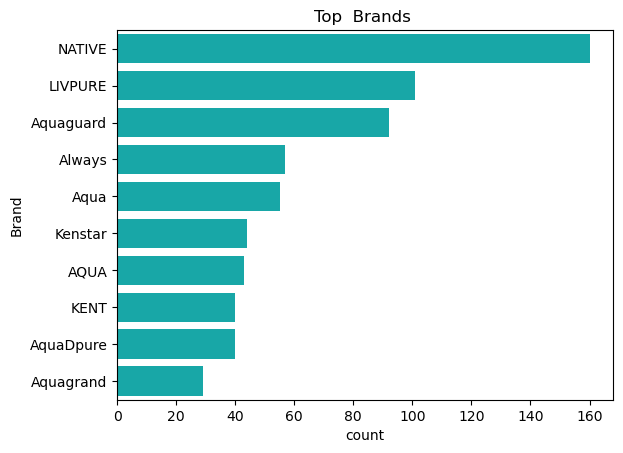

In [45]:
# Visualize top brands using countplot
sns.countplot(y="Brand", data=df, order=df["Brand"].value_counts().head(10).index,color='c')
plt.title("Top  Brands ")

plt.show()

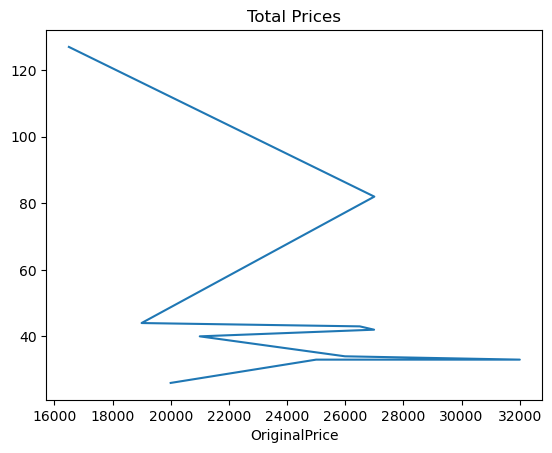

In [46]:
# Line plot of the top 10 most frequent OriginalPrice values
df['OriginalPrice'].value_counts().head(10).plot(kind = 'line')
plt.title('Total Prices')
plt.show()

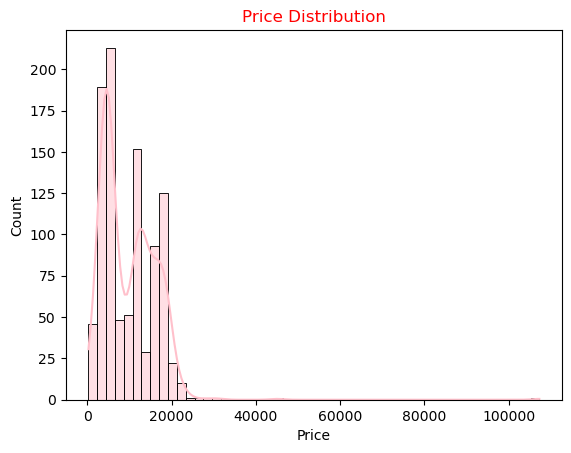

In [47]:
# Histogram of product prices with density curve
sns.histplot(x=df["Price"],kde=True,data=df,color='pink')
plt.title("Price Distribution",color='Red')
plt.show()

In [48]:
## Outlier detection based on IQR rule
q1=df["Price"].quantile(0.25)
q3=df["Price"].quantile(0.75)
iqr=q3-q1
outliers=df[(df["Price"]<q1-1.5*iqr) | (df["Price"]>q3+1.5*iqr)]
outliers

,Brand,Price,Ratings,pagenum,OriginalPrice,Discount,Specifications,Warranty,capacity,No.of ratings,No.of reviews
502,AO,31098,4.4,21,31100,66%,Electrical & StorageALL,nan,nan,24,7
728,Izumi,107266,4.2,31,109999,2%,Electrical & StorageRepair,nan,nan,10672,1014
902,Karofi,45007,4.2,38,69999,35%,Electrical & Non,1,nan,10672,1014


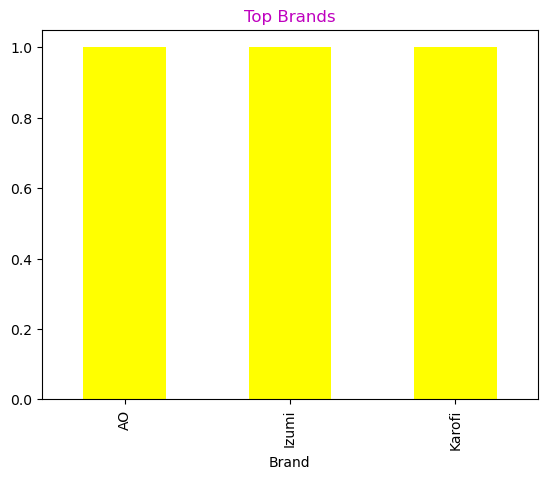

In [49]:
# Visualize brands most frequently appearing in outlier products
outliers["Brand"].value_counts().head().plot(kind="bar",color='yellow')
plt.title("Top Brands",color='m')
plt.show()

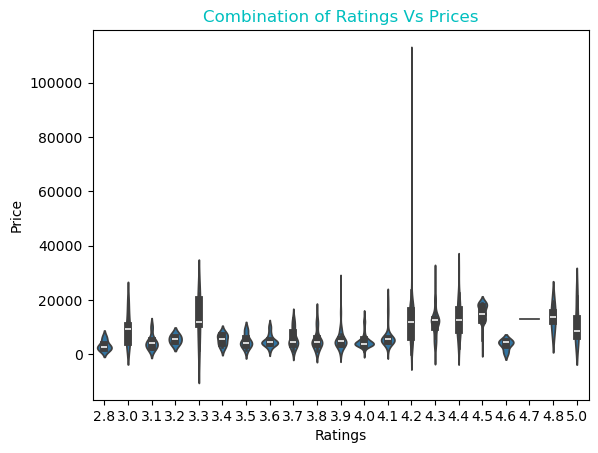

In [50]:
# Violin plot showing price distribution across ratings
sns.violinplot(x="Ratings",y="Price",data=df)
plt.title('Combination of Ratings Vs Prices',color='c')
plt.show()

# Bivariate Analysis

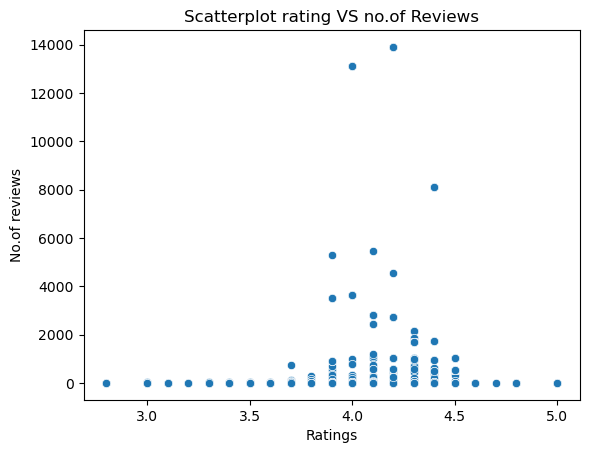

In [51]:
# Scatter plot of ratings vs number of reviews
sns.scatterplot(x="Ratings",y="No.of reviews",data=df)
plt.title("Scatterplot rating VS no.of Reviews")
plt.show()

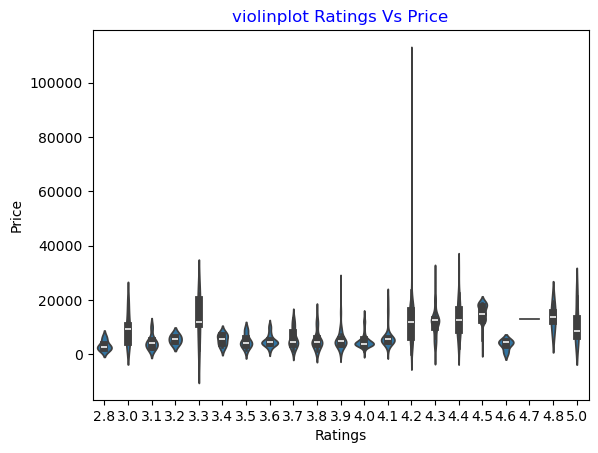

In [52]:
# Violin plot showing distribution of prices across ratings
sns.violinplot(x="Ratings",y="Price",data=df)
plt.title("violinplot Ratings Vs Price",color='blue')
plt.show()

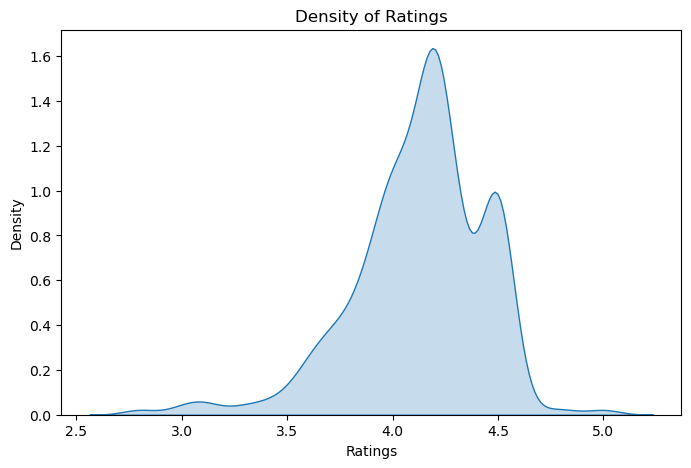

In [53]:
# KDE plot showing distribution of product ratings
plt.figure(figsize=(8,5))
sns.kdeplot(df['Ratings'], fill=True)
plt.title("Density of Ratings")
plt.show()

# Multivariate Analysis

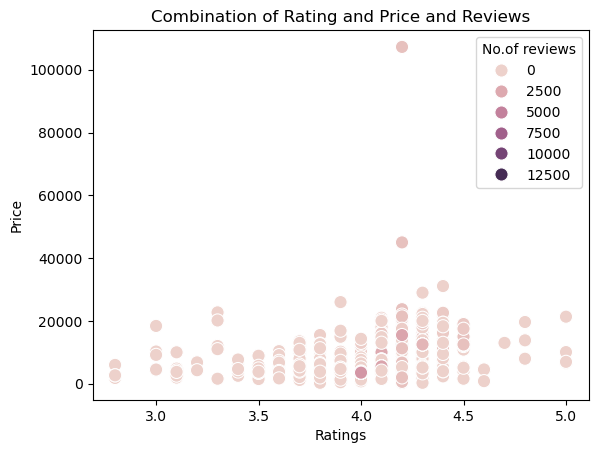

In [54]:
# Scatter plot of ratings vs price with review count as hue
sns.scatterplot(x="Ratings",y="Price",hue="No.of reviews",data=df,s=90)
plt.title("Combination of Rating and Price and Reviews")
plt.show()

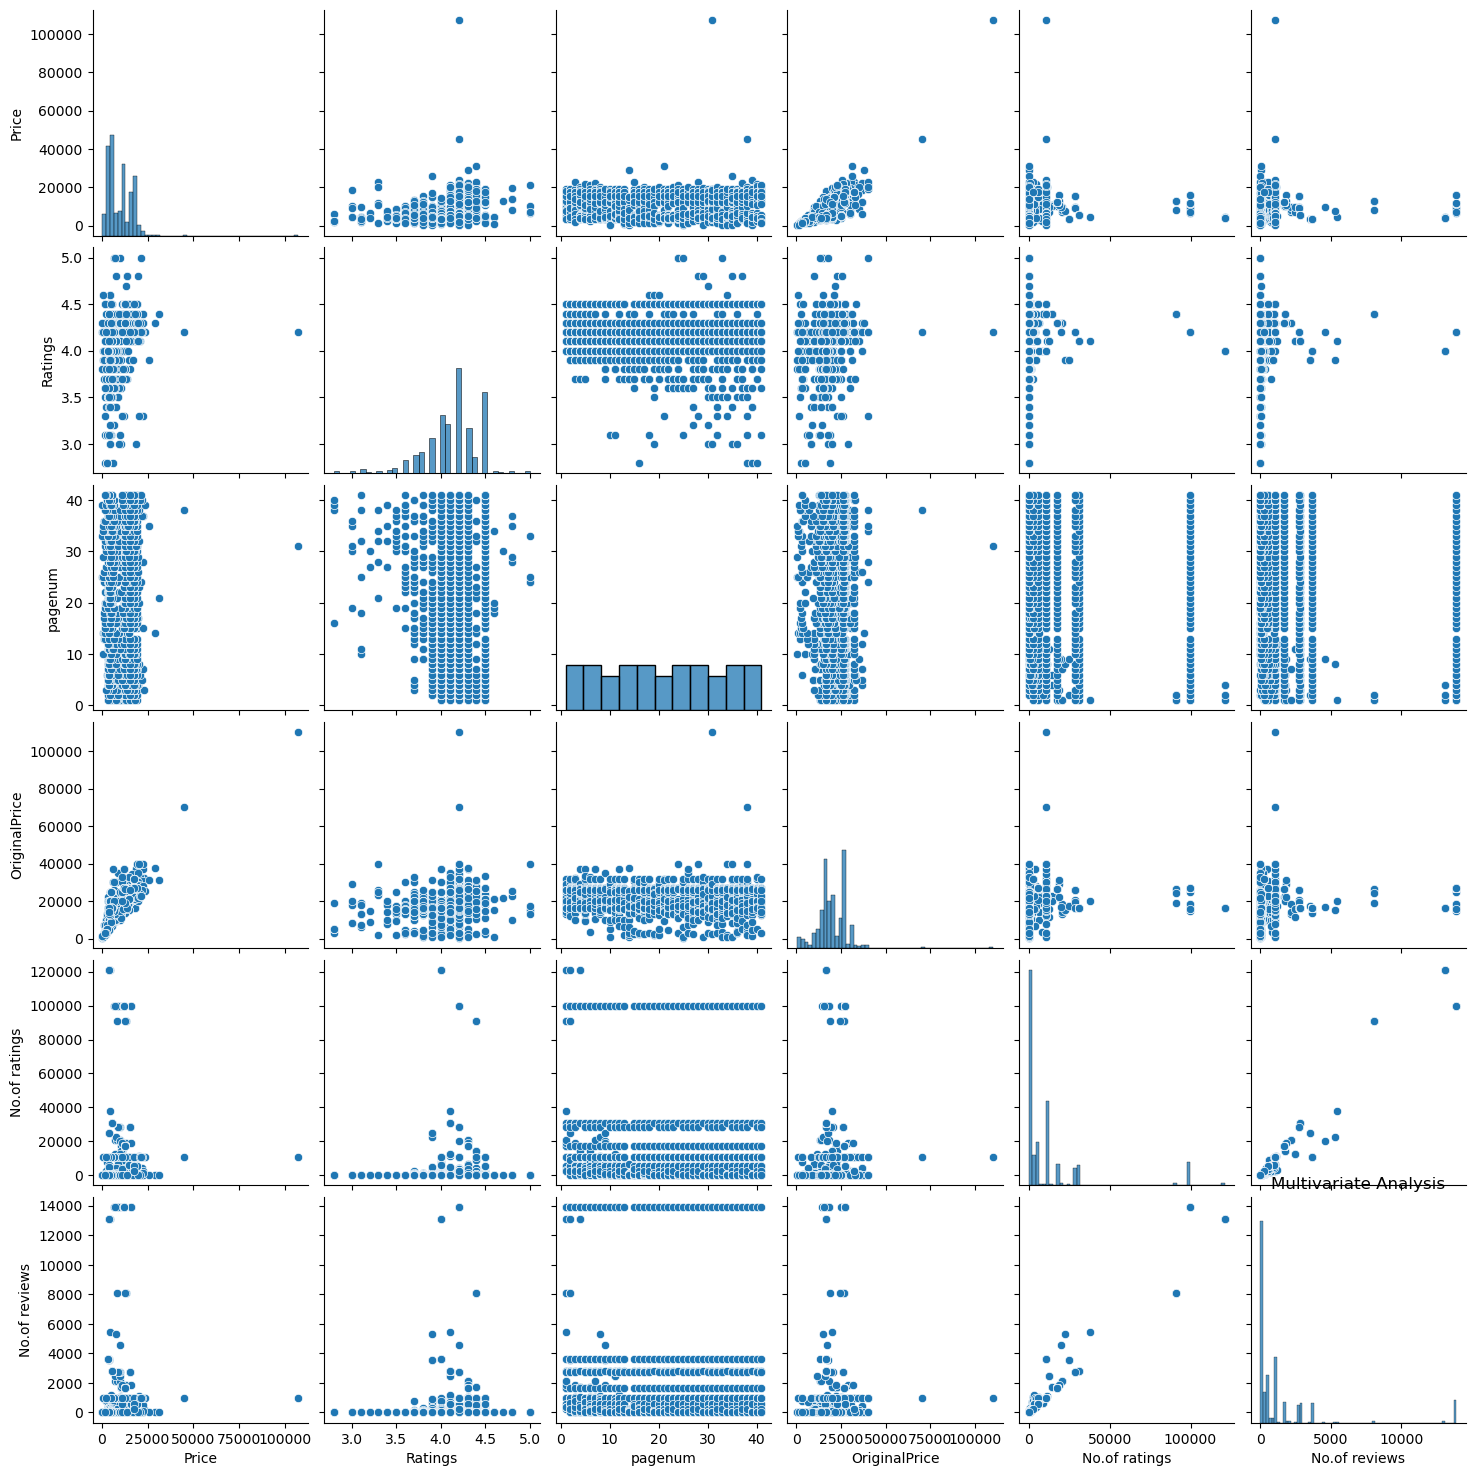

In [55]:
# Pairplot for multivariate analysis of numerical features
sns.pairplot(df)
plt.title("Multivariate Analysis")
plt.show()

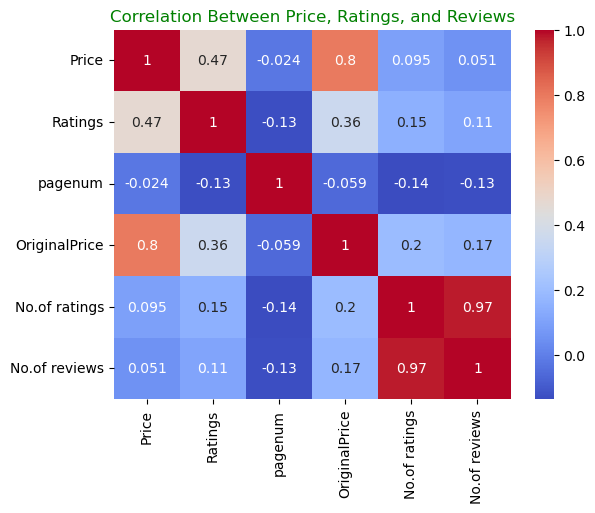

In [56]:
sns.heatmap(df.select_dtypes(include="number").corr(),annot=True,cmap="coolwarm")
plt.title("Correlation Between Price, Ratings, and Reviews",color='green')
plt.show()

# Conclusion

This project demonstrates practical skills in:

- Web Scraping using BeautifulSoup
- Data Cleaning using Pandas
- Exploratory Data Analysis (EDA)
- Data Visualization using Matplotlib
- Business Insight Generation

The analysis helps identify pricing trends and customer preferences for Flipkart water purifiers, supporting data-driven decision-making.